# Chapter 66 — Feedforward Networks Inside Transformers

Attention and feedforward networks perform different jobs inside a transformer block.

Attention exchanges information across positions.

A feedforward network then transforms each position independently with the same learned function.


## Learning goals

By the end of this chapter, you will be able to:

- distinguish the jobs of attention and a feedforward network;
- implement a position-wise feedforward network with `torch.nn.Sequential`;
- trace the shapes through an `embedding → hidden → embedding` transformation;
- explain why a nonlinear activation is necessary;
- demonstrate that the network neither mixes positions nor uses position-specific parameters;
- count its parameters; and
- place it inside a pre-normalized residual sublayer.


## Two complementary jobs

A transformer block contains two main learned sublayers.

| Sublayer | Main job | Mixes positions directly? |
|---|---|---|
| Causal self-attention | Gather information from the current and earlier positions | Yes |
| Feedforward network | Transform the features at each position | No |

The feedforward network is **position-wise** because it applies the same neural network separately at every position.

Its input may already contain contextual information gathered by attention, even though the feedforward operation itself does not look across positions.


## Shape notation

We will use these symbols:

- `B` is the batch size.
- `T` is the context length.
- `C` is the embedding dimension.
- `F` is the hidden dimension inside the feedforward network.

The teaching example uses an expansion factor of `4`, so `F = 4C`.

The shape path is `[B, T, C] → [B, T, F] → [B, T, C]`.


## Create transformer-shaped input

The following cell creates a deterministic batch with two sequences, four positions per sequence, and eight features per position.


In [1]:
import torch

device = "cpu"
torch.manual_seed(66)

batch_size = 2
context_length = 4
embedding_dimension = 8
expansion_factor = 4
hidden_dimension = expansion_factor * embedding_dimension

input_vectors = torch.randn(
    batch_size,
    context_length,
    embedding_dimension,
    device=device,
)

print("device:", device)
print("input shape:", input_vectors.shape)
print("hidden dimension:", hidden_dimension)

device: cpu
input shape: torch.Size([2, 4, 8])
hidden dimension: 32


The input shape is `[2, 4, 8]`, and the expanded hidden dimension is `32`.

Only the final feature dimension will change inside the network.


## Build the feedforward network

A simple teaching implementation expands each vector, applies ReLU, and projects it back to the embedding dimension.


In [2]:
feedforward_network = torch.nn.Sequential(
    torch.nn.Linear(embedding_dimension, hidden_dimension),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden_dimension, embedding_dimension),
).to(device)

print(feedforward_network)

Sequential(
  (0): Linear(in_features=8, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=8, bias=True)
)


The wider hidden layer gives the network more intermediate features and parameters with which to learn a transformation.

The final projection restores dimension `C`, which will make an exact-shape residual addition possible.


## Trace every intermediate shape

A PyTorch linear layer transforms only the last dimension and preserves every leading dimension.

Applying the three layers separately exposes the complete shape path.


In [3]:
hidden_values_before_relu = feedforward_network[0](input_vectors)
hidden_values_after_relu = feedforward_network[1](hidden_values_before_relu)
output_vectors = feedforward_network[2](hidden_values_after_relu)
direct_output_vectors = feedforward_network(input_vectors)

print("input:             ", input_vectors.shape)
print("hidden before ReLU:", hidden_values_before_relu.shape)
print("hidden after ReLU: ", hidden_values_after_relu.shape)
print("output:            ", output_vectors.shape)
print("stepwise output matches Sequential:", end=" ")
print(torch.allclose(output_vectors, direct_output_vectors))

input:              torch.Size([2, 4, 8])
hidden before ReLU: torch.Size([2, 4, 32])
hidden after ReLU:  torch.Size([2, 4, 32])
output:             torch.Size([2, 4, 8])
stepwise output matches Sequential: True


The batch size and context length remain `2` and `4` at every step.

The feature dimension follows `8 → 32 → 32 → 8`.


## Why the activation matters

ReLU applies `max(0, value)` independently to every hidden feature.

Without a nonlinear activation, two affine linear layers can be combined into one affine linear layer, so the expanded representation would not provide the same expressive benefit.

ReLU keeps this first implementation easy to inspect.

Many GPT-family architectures instead use GELU or a gated activation, but their feedforward sublayers remain position-wise.


The next cell visualizes how ReLU changes the 32 hidden features for one position.


negative values before ReLU: 18
zero values after ReLU: 18


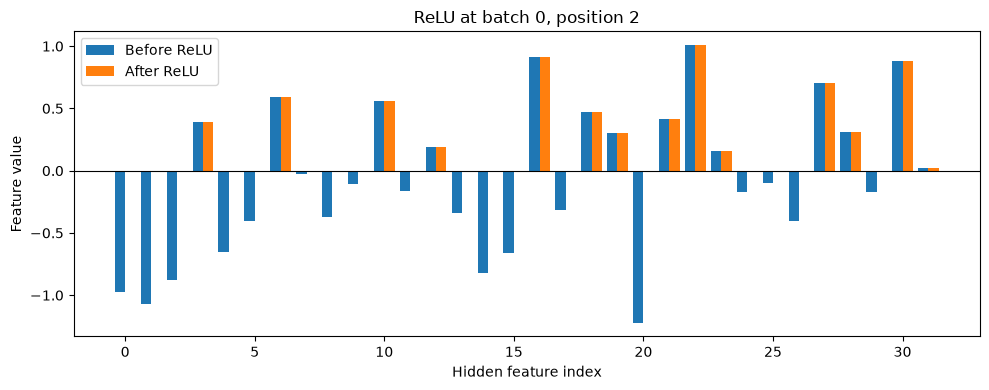

In [4]:
import matplotlib.pyplot as plt

selected_hidden_before = hidden_values_before_relu[0, 2].detach()
selected_hidden_after = hidden_values_after_relu[0, 2].detach()
hidden_feature_indexes = torch.arange(hidden_dimension)

print("negative values before ReLU:", (selected_hidden_before < 0).sum().item())
print("zero values after ReLU:", (selected_hidden_after == 0).sum().item())

plt.figure(figsize=(10, 4))
plt.bar(
    hidden_feature_indexes - 0.2,
    selected_hidden_before,
    width=0.4,
    label="Before ReLU",
)
plt.bar(
    hidden_feature_indexes + 0.2,
    selected_hidden_after,
    width=0.4,
    label="After ReLU",
)
plt.axhline(0.0, color="black", linewidth=0.8)
plt.xlabel("Hidden feature index")
plt.ylabel("Feature value")
plt.title("ReLU at batch 0, position 2")
plt.legend()
plt.tight_layout()
plt.show()

Every negative pre-activation becomes zero, while positive values remain unchanged.


## Prove that positions do not mix

The biases can make a zero input produce a nonzero output, so the correct test compares output differences.

We will change only position `1` and verify that no other output position changes.


In [5]:
base_input_vectors = torch.zeros(
    1,
    3,
    embedding_dimension,
    device=device,
)
changed_input_vectors = base_input_vectors.clone()
changed_input_vectors[0, 1, 0] = 10.0

base_output = feedforward_network(base_input_vectors)
changed_output = feedforward_network(changed_input_vectors)
change_per_position = (changed_output - base_output).abs().sum(dim=-1)

print("absolute output change per position:")
print(change_per_position)
print("position 0 unchanged:", torch.allclose(base_output[:, 0], changed_output[:, 0]))
print("position 2 unchanged:", torch.allclose(base_output[:, 2], changed_output[:, 2]))

absolute output change per position:
tensor([[0.0000, 6.0896, 0.0000]], grad_fn=<SumBackward1>)
position 0 unchanged: True
position 2 unchanged: True


Only position `1` has a nonzero output difference.

Attention could propagate a change to other allowed positions, but this feedforward network cannot.


## Prove that parameters are shared across positions

Position-wise does not mean that every position owns a different network.

Running one vector alone should match running that vector at its position in the batch.

Reordering positions should simply reorder their outputs.


In [6]:
single_position_vector = input_vectors[0, 2]
single_position_output = feedforward_network(single_position_vector)
batched_position_output = feedforward_network(input_vectors)[0, 2]

position_order = torch.tensor([2, 0, 3, 1], device=device)
reordered_inputs = input_vectors[:, position_order]
reordered_outputs = feedforward_network(reordered_inputs)
expected_reordered_outputs = feedforward_network(input_vectors)[:, position_order]

print("single and batched position outputs match:", end=" ")
print(torch.allclose(single_position_output, batched_position_output))
print("reordering inputs only reorders outputs:", end=" ")
print(torch.allclose(reordered_outputs, expected_reordered_outputs))

single and batched position outputs match: True
reordering inputs only reorders outputs: True


Both checks pass because one set of weights is reused independently at every position.

The network has no direct access to a position index unless that information is already encoded in the input vector.


## Count the parameters

For expansion factor `r`, the two linear layers contain `2rC² + (r + 1)C` parameters when both layers use biases.

With `C = 8` and `r = 4`, that total is `552`.


In [7]:
def count_parameters(module: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in module.parameters())


formula_parameter_count = (
    2 * expansion_factor * embedding_dimension**2
    + (expansion_factor + 1) * embedding_dimension
)

for parameter_name, parameter in feedforward_network.named_parameters():
    shape_text = str(parameter.shape)
    parameter_count = parameter.numel()
    print(f"{parameter_name:10} {shape_text:18} {parameter_count:3} parameters")

print("counted total:", count_parameters(feedforward_network))
print("formula total:", formula_parameter_count)

0.weight   torch.Size([32, 8]) 256 parameters
0.bias     torch.Size([32])    32 parameters
2.weight   torch.Size([8, 32]) 256 parameters
2.bias     torch.Size([8])      8 parameters
counted total: 552
formula total: 552


The first and second weight matrices account for most of the parameters.

Increasing the hidden width therefore increases both capacity and computation.


## Return to the embedding dimension

A transformer residual branch is intended to return exactly the input shape.

The second linear layer makes `[B, T, C] + [B, T, C]` possible.


In [8]:
feedforward_change = feedforward_network(input_vectors)
values_after_residual = input_vectors + feedforward_change
expanded_only_output = feedforward_network[:2](input_vectors)

print("input shape:              ", input_vectors.shape)
print("feedforward change shape: ", feedforward_change.shape)
print("residual result shape:    ", values_after_residual.shape)
print("expanded-only shape:      ", expanded_only_output.shape)
print("residual shapes match exactly:", input_vectors.shape == feedforward_change.shape)
print(
    "expanded-only shape matches:   ", input_vectors.shape == expanded_only_output.shape
)

input shape:               torch.Size([2, 4, 8])
feedforward change shape:  torch.Size([2, 4, 8])
residual result shape:     torch.Size([2, 4, 8])
expanded-only shape:       torch.Size([2, 4, 32])
residual shapes match exactly: True
expanded-only shape matches:    False


The full network returns `[2, 4, 8]`, while stopping after expansion returns `[2, 4, 32]`.

The expanded-only tensor cannot serve as the change in this residual addition.


## Package a reusable module

The following module validates its public dimensions and exposes intermediate values for inspection.


In [9]:
class PositionWiseFeedForward(torch.nn.Module):
    """Apply one shared feedforward network to the last tensor dimension."""

    embedding_dimension: int
    expansion_factor: int
    hidden_dimension: int
    network: torch.nn.Sequential

    def __init__(self, embedding_dimension: int, expansion_factor: int = 4) -> None:
        super().__init__()

        if embedding_dimension <= 0:
            raise ValueError("embedding_dimension must be positive.")
        if expansion_factor <= 0:
            raise ValueError("expansion_factor must be positive.")

        self.embedding_dimension = embedding_dimension
        self.expansion_factor = expansion_factor
        self.hidden_dimension = expansion_factor * embedding_dimension
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, self.hidden_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(self.hidden_dimension, embedding_dimension),
        )

    def _validate_input(self, input_vectors: torch.Tensor) -> None:
        if input_vectors.shape[-1] != self.embedding_dimension:
            raise ValueError(
                "The last input dimension must equal embedding_dimension. "
                f"Received {input_vectors.shape[-1]} and expected "
                f"{self.embedding_dimension}."
            )

    def forward(self, input_vectors: torch.Tensor) -> torch.Tensor:
        self._validate_input(input_vectors)
        return self.network(input_vectors)

    def forward_with_intermediates(
        self, input_vectors: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        self._validate_input(input_vectors)
        hidden_before_relu = self.network[0](input_vectors)
        hidden_after_relu = self.network[1](hidden_before_relu)
        output_vectors = self.network[2](hidden_after_relu)
        return hidden_before_relu, hidden_after_relu, output_vectors


torch.manual_seed(66)
feedforward_module = PositionWiseFeedForward(
    embedding_dimension=embedding_dimension,
    expansion_factor=expansion_factor,
).to(device)

module_intermediates = feedforward_module.forward_with_intermediates(input_vectors)
module_output = feedforward_module(input_vectors)

print("hidden before ReLU:", module_intermediates[0].shape)
print("hidden after ReLU: ", module_intermediates[1].shape)
print("module output:     ", module_output.shape)
print("inspection output matches forward:", end=" ")
print(torch.allclose(module_intermediates[2], module_output))

hidden before ReLU: torch.Size([2, 4, 32])
hidden after ReLU:  torch.Size([2, 4, 32])
module output:      torch.Size([2, 4, 8])
inspection output matches forward: True


The reusable module performs the same `C → 4C → C` operation while checking the external feature-size contract.


## Add pre-normalization and a residual connection

Chapter 65 introduced the pre-normalized residual pattern.

For the feedforward sublayer, that pattern is `output = input + feedforward(layer_norm(input))`.

This is one sublayer of a transformer block, not yet the complete block.


In [10]:
class PreNormFeedForwardResidual(torch.nn.Module):
    """Apply LayerNorm, a position-wise feedforward branch, and a residual add."""

    layer_norm: torch.nn.LayerNorm
    feedforward: PositionWiseFeedForward

    def __init__(self, embedding_dimension: int, expansion_factor: int = 4) -> None:
        super().__init__()
        self.layer_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = PositionWiseFeedForward(
            embedding_dimension=embedding_dimension,
            expansion_factor=expansion_factor,
        )

    def forward(self, input_vectors: torch.Tensor) -> torch.Tensor:
        normalized_vectors = self.layer_norm(input_vectors)
        feedforward_change = self.feedforward(normalized_vectors)
        return input_vectors + feedforward_change


torch.manual_seed(66)
feedforward_residual = PreNormFeedForwardResidual(
    embedding_dimension=embedding_dimension,
).to(device)

normalized_vectors = feedforward_residual.layer_norm(input_vectors)
feedforward_change = feedforward_residual.feedforward(normalized_vectors)
manual_residual_output = input_vectors + feedforward_change
residual_output = feedforward_residual(input_vectors)

print("input:             ", input_vectors.shape)
print("normalized:        ", normalized_vectors.shape)
print("feedforward change:", feedforward_change.shape)
print("residual output:   ", residual_output.shape)
print("manual residual arithmetic matches:", end=" ")
print(torch.allclose(manual_residual_output, residual_output))

input:              torch.Size([2, 4, 8])
normalized:         torch.Size([2, 4, 8])
feedforward change: torch.Size([2, 4, 8])
residual output:    torch.Size([2, 4, 8])
manual residual arithmetic matches: True


Layer normalization, the feedforward branch, and residual addition all preserve `[B, T, C]` at their external boundaries.

The temporary expansion to `[B, T, 4C]` exists only inside the feedforward branch.


## Shape summary

| Value | Shape | Meaning |
|---|---|---|
| Input | `[B, T, C]` | One `C`-feature vector per position |
| Hidden pre-activation | `[B, T, 4C]` | Expanded features before ReLU |
| Hidden activation | `[B, T, 4C]` | Expanded features after ReLU |
| Feedforward output | `[B, T, C]` | Position-wise learned change |
| Residual output | `[B, T, C]` | Original values plus that change |

Neither `B` nor `T` changes during the feedforward computation.


## Common mistakes

- Do not claim that the feedforward network exchanges information across positions.
- Do not confuse hidden width `4C` with four context dimensions.
- Do not create separate feedforward parameters for different positions.
- Do not omit the nonlinear activation and expect the same expressive transformation.
- Do not stop at hidden dimension `4C` when an exact-shape residual addition requires `C`.
- Do not assume that ReLU is the only activation used in transformer feedforward networks.


## Takeaways

A transformer feedforward network applies one shared neural network independently to every position.

Its simple teaching structure is `Linear(C, 4C) → ReLU → Linear(4C, C)`.

The temporary expansion increases the internal feature width, and the final projection restores the embedding dimension.

The central distinction is:

> Attention mixes information across positions.
>
> The feedforward network transforms each position independently.

Returning to shape `[B, T, C]` lets the feedforward result participate in a residual connection.


## What comes next

The next chapter combines causal multi-head attention and this position-wise feedforward network into a complete pre-normalized transformer block.

That block will use two layer normalizations and two residual connections while preserving `[B, T, C]` throughout.
